# Preprocessing Transactions

This file preprocesses the transaction data 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys, os, glob
import re
import zipfile
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, LongType, IntegerType, DateType, DoubleType
from datetime import datetime, timedelta

In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/18 16:52:20 WARN Utils: Your hostname, CompuPau, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/18 16:52:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/18 16:52:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# Unzip the data files
zip_file_path = [
    "../data/project-2-bnpl-tables-part1.zip",
    "../data/project-2-bnpl-tables-part2.zip",
    "../data/project-2-bnpl-tables-part3.zip",
    "../data/project-2-bnpl-tables-part4.zip"
]

for zip_path in zip_file_path:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("../data/")
    

In [4]:
transactions1 = spark.read.parquet(".././data/tables/transactions_20210228_20210827_snapshot")
transactions2 = spark.read.parquet(".././data/tables/transactions_20210828_20220227_snapshot")
transactions3 = spark.read.parquet(".././data/tables/transactions_20220228_20220828_snapshot")

transactions1.write.mode('overwrite').parquet('.././data/landing/transactions/transactions1')
transactions2.write.mode('overwrite').parquet('.././data/landing/transactions/transactions2')
transactions3.write.mode('overwrite').parquet('.././data/landing/transactions/transactions3')

In [5]:
transactions = transactions1.union(transactions2).union(transactions3)

transactions.show()
transactions.count()

+-------+------------+------------------+--------------------+--------------+
|user_id|merchant_abn|      dollar_value|            order_id|order_datetime|
+-------+------------+------------------+--------------------+--------------+
|  18478| 62191208634|63.255848959735246|949a63c8-29f7-4ab...|    2021-08-20|
|      2| 15549624934| 130.3505283105634|6a84c3cf-612a-457...|    2021-08-20|
|  18479| 64403598239|120.15860593212783|b10dcc33-e53f-425...|    2021-08-20|
|      3| 60956456424| 136.6785200286976|0f09c5a5-784e-447...|    2021-08-20|
|  18479| 94493496784| 72.96316578355305|f6c78c1a-4600-4c5...|    2021-08-20|
|      3| 76819856970|  448.529684285612|5ace6a24-cdf0-4aa...|    2021-08-20|
|  18479| 67609108741|  86.4040605836911|d0e180f0-cb06-42a...|    2021-08-20|
|      3| 34096466752| 301.5793450525113|6fb1ff48-24bb-4f9...|    2021-08-20|
|  18482| 70501974849| 68.75486276223054|8505fb33-b69a-412...|    2021-08-20|
|      4| 49891706470| 48.89796461900801|ed11e477-b09f-4ae...|  

14195505

In [6]:
transactions.write.mode('overwrite').parquet('.././data/raw/transactions/full_transactions')
transactions = spark.read.parquet(".././data/raw/transactions/full_transactions")
transactions.show(truncate = False)

+-------+------------+------------------+------------------------------------+--------------+
|user_id|merchant_abn|dollar_value      |order_id                            |order_datetime|
+-------+------------+------------------+------------------------------------+--------------+
|14935  |79417999332 |136.06570809815838|23acbb7b-cf98-4580-9775-86b8e0a2bd88|2021-11-26    |
|1      |46451548968 |72.61581642788431 |76bab304-fa2d-4004-8179-8638b56a873e|2021-11-26    |
|14936  |89518629617 |3.0783487174439297|a2ae446a-2959-41c4-81fd-a30c1efbde0c|2021-11-26    |
|1      |49167531725 |51.58228625503599 |7080c274-17f7-4ccf-be22-1d33a45f7f81|2021-11-26    |
|14936  |31101120643 |25.228114942417797|8e301c0f-06ab-45cb-a573-47c8e9b95423|2021-11-26    |
|2      |67978471888 |691.5028234458998 |0380e9ad-b0e8-4203-a74b-e4ad3504d643|2021-11-26    |
|14936  |60956456424 |102.13952056640888|5ac3da9c-5147-4524-8efb-0d312cfe6748|2021-11-26    |
|2      |47644196714 |644.5220654863093 |4e368e44-86f8-4dee-

# Schema

In [7]:
transactions.printSchema()

root
 |-- user_id: long (nullable = true)
 |-- merchant_abn: long (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)



Ensure all datatypes are consistent across tables.

In [8]:
transactions = transactions.withColumn('user_id', F.col('user_id').cast(StringType()))
transactions = transactions.withColumn('merchant_abn', F.col('merchant_abn').cast(StringType()))
transactions.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)



# Missing Value Detection

In [9]:
transactions.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in transactions.columns
]).show()

+-------+------------+------------+--------+--------------+
|user_id|merchant_abn|dollar_value|order_id|order_datetime|
+-------+------------+------------+--------+--------------+
|      0|           0|           0|       0|             0|
+-------+------------+------------+--------+--------------+



# Business Filtering Rule

`dollar value` for any transaction needs be greater than 0.

In [10]:
def report_shape(df, label):
    n = df.count()
    print(f"{label}: {n:,} rows")
    return n

n0 = report_shape(transactions, "0. raw transactions")

# --- Business-rule filtering ---
# dollar_value must be strictly positive -- a $0 or negative transaction
# isn't a real purchase (refunds/corrections, if any, aren't modelled here).
step1 = transactions.filter(F.col("dollar_value") > 0)
n1 = report_shape(step1, "1. dollar_value > 0")

clean = step1
print(f"Retained: {n1:,} / {n0:,} ({n1/n0:.1%})")

0. raw transactions: 14,195,505 rows
1. dollar_value > 0: 14,195,505 rows
Retained: 14,195,505 / 14,195,505 (100.0%)


# Outlier Removal

Outlier removal on `dollar_value` (log-N IQR rule). Raw dollar_value is right-skewed (many small purchases, a long tail of large ones), so IQR is computed on log1p(dollar_value) rather than the raw scale. Per the log-N rule: flag values more than k x IQR from the box, where k = sqrt(log n) - 0.5 for n > 100.

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


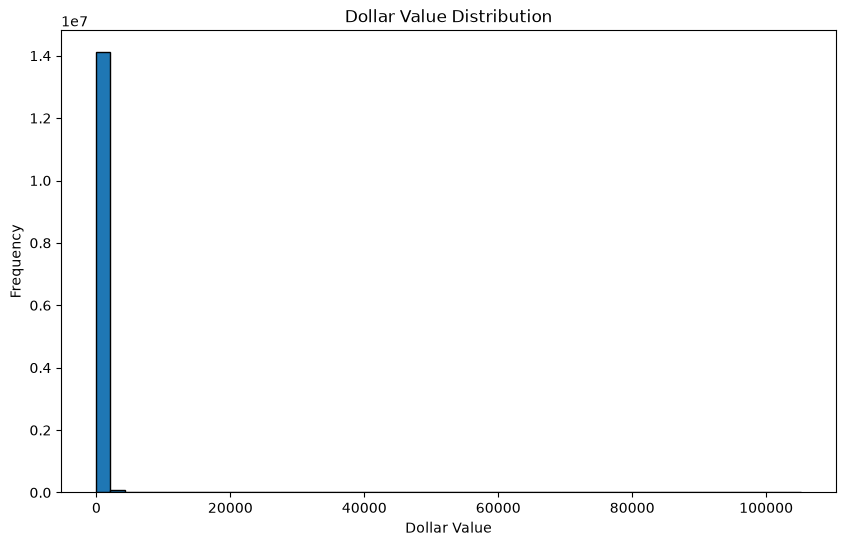

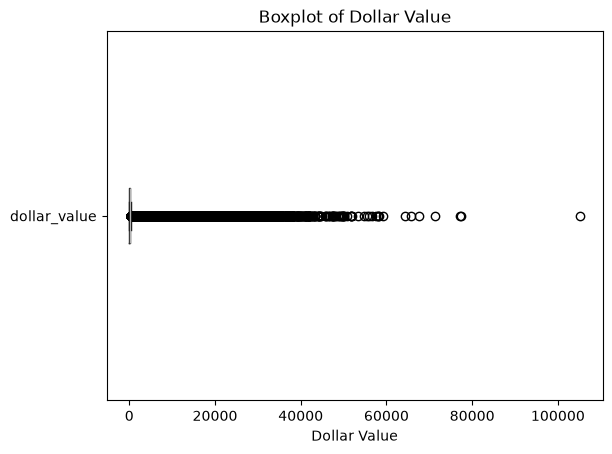

In [11]:
dollar = transactions.select("dollar_value").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(dollar["dollar_value"], bins=50, edgecolor="black")
plt.xlabel("Dollar Value")
plt.ylabel("Frequency")
plt.title("Dollar Value Distribution")
plt.show()

dollar.boxplot(column="dollar_value", vert=False, grid=False)
plt.xlabel("Dollar Value")
plt.title("Boxplot of Dollar Value")
plt.show()

In [12]:
clean = clean.withColumn("log_dollar_value", F.log1p(F.col("dollar_value")))

n_rows = clean.count()
k = np.sqrt(np.log(n_rows)) - 0.5

q1, q3 = clean.approxQuantile("log_dollar_value", [0.25, 0.75], 0.0)
iqr = q3 - q1

lower_bound = q1 - k * iqr
upper_bound = q3 + k * iqr

print(f"n = {n_rows:,}, k = {k:.4f}")
print(f"Log-scale Q1: {q1:.4f}, Q3: {q3:.4f}, IQR: {iqr:.4f}")
print(f"Log-scale bounds: [{lower_bound:.4f}, {upper_bound:.4f}]")

n_before_outlier = report_shape(clean, "2. before outlier removal")

curated = clean.filter(
    (F.col("log_dollar_value") >= lower_bound) &
    (F.col("log_dollar_value") <= upper_bound)
).drop("log_dollar_value")

n_after_outlier = report_shape(curated, "3. after log-N IQR outlier removal")
print(f"Removed as outliers: {n_before_outlier - n_after_outlier:,}")

print(f"\nTotal retained: {n_after_outlier:,} / {n0:,} ({n_after_outlier/n0:.1%})")

n = 14,195,505, k = 3.5581
Log-scale Q1: 3.3006, Q3: 5.0203, IQR: 1.7196
Log-scale bounds: [-2.8181, 11.1390]
2. before outlier removal: 14,195,505 rows
3. after log-N IQR outlier removal: 14,195,501 rows
Removed as outliers: 4

Total retained: 14,195,501 / 14,195,505 (100.0%)


Store curated transaction dataset

In [13]:
transactions.write.mode("overwrite").parquet("../data/curated/transactions/")

# Join with Consumers data

Join on `user_id` and `order_datetime`.

In [14]:
consumer_demographics = spark.read.parquet("../data/curated/df_customers_demo/")
consumer_demographics.show(truncate = False)

+-------+-----------+------------------+----------------------------------+-----+--------+-----------+
|user_id|consumer_id|name              |address                           |state|postcode|gender     |
+-------+-----------+------------------+----------------------------------+-----+--------+-----------+
|13     |1146717    |Angela Brown PhD  |0236 Mills Land Suite 203         |QLD  |4673    |Female     |
|16     |1356405    |Tracy Hart        |9671 Jacob Harbors Suite 431      |NSW  |2452    |Male       |
|18     |80965      |Michael Burnett   |89400 Torres Fort                 |NSW  |1109    |Male       |
|20     |1390367    |James Norris      |790 Ramos Landing                 |VIC  |3234    |Undisclosed|
|21     |298861     |Wendy Singh       |903 Holder Freeway Apt. 374       |SA   |5353    |Female     |
|24     |1382646    |Jeffrey Moreno    |339 Philip Pike                   |TAS  |7173    |Male       |
|38     |1230828    |Kiara Smith MD    |7081 Davis Tunnel                

In [15]:
consumer_fraud = spark.read.parquet("../data/curated/consumer_fraud_probability/")
consumer_fraud.show(truncate = False)

+-------+--------------+------------------+---------------------+
|user_id|order_datetime|fraud_probability |is_same_day_duplicate|
+-------+--------------+------------------+---------------------+
|1      |2022-02-20    |9.805431136520959 |false                |
|2      |2021-08-30    |9.599513915425788 |false                |
|2      |2021-09-25    |10.069850934775245|false                |
|3      |2021-11-03    |8.300636455314633 |false                |
|4      |2021-10-09    |9.633302411090419 |false                |
|5      |2021-10-04    |10.868364868449886|false                |
|5      |2022-01-11    |27.496186536467164|false                |
|5      |2022-02-08    |9.02022421158597  |false                |
|6      |2021-12-12    |10.459280127078758|false                |
|9      |2021-11-17    |8.531261989227714 |false                |
|9      |2021-12-13    |10.58055311139687 |false                |
|13     |2021-07-17    |9.050002342172851 |false                |
|13     |2

In [16]:
consumer_demographics.printSchema()
consumer_demographics.count() 

root
 |-- user_id: long (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)



499999

In [17]:
consumer_fraud.printSchema()
consumer_fraud.count() 

root
 |-- user_id: long (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)



34864

In [18]:
transaction_cols = set(transactions.columns)

demo_cols = set(consumer_demographics.columns)
overlapping_demo = transaction_cols & demo_cols
print("Overlap con consumer_demo:", overlapping_demo)

fraud_cols = set(consumer_fraud.columns)
overlapping_fraud = transaction_cols & fraud_cols
print("Overlap con consumer_fraud:", overlapping_fraud)

Overlap con consumer_demo: {'user_id'}
Overlap con consumer_fraud: {'order_datetime', 'user_id'}


In [19]:
transactions.count()

14195505

In [20]:
# join transactions with consumer_demographics and consumer_fraud
# this way we can know the transactions that have fraud probability for consumers.
c_transactions = (
    transactions
    .join(consumer_demographics, on="user_id", how="left")
    .join(consumer_fraud, on=["user_id", "order_datetime"], how="left")
)

c_transactions.show()

+-------+--------------+------------+------------------+--------------------+-----------+-------------------+--------------------+-----+--------+-----------+-----------------+---------------------+
|user_id|order_datetime|merchant_abn|      dollar_value|            order_id|consumer_id|               name|             address|state|postcode|     gender|fraud_probability|is_same_day_duplicate|
+-------+--------------+------------+------------------+--------------------+-----------+-------------------+--------------------+-----+--------+-----------+-----------------+---------------------+
|      2|    2021-11-26| 67978471888| 691.5028234458998|0380e9ad-b0e8-420...|     179208|         Mary Smith|     3764 Amber Oval|  NSW|    2782|     Female|             NULL|                 NULL|
|      2|    2021-11-26| 47644196714| 644.5220654863093|4e368e44-86f8-4de...|     179208|         Mary Smith|     3764 Amber Oval|  NSW|    2782|     Female|             NULL|                 NULL|
|      2| 

In [21]:
c_transactions.printSchema()
c_transactions.count()

root
 |-- user_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)



14195717

We have more records than before, we will check these duplicates.

# Check for duplicates

In [23]:
# count the difference in rows between the original transactions and the joined c_transactions
diff = c_transactions.count() - transactions.count()
diff

212

In [24]:
# see were the extra rows come from
dup = consumer_fraud.groupBy("user_id", "order_datetime").count().filter(F.col("count") > 1)
print("Duplicates:", dup.count())

Duplicates: 99


In [25]:
# see duplicates by user_id and order_datetime
dup_combos = consumer_fraud.groupBy("user_id", "order_datetime") \
    .count().filter(F.col("count") > 1) \
    .withColumnRenamed("count", "n_fraud_rows")

# how many real transactions exist for each of those duplicate groups
txns_per_combo = transactions.join(
    dup_combos.select("user_id", "order_datetime"),
    on=["user_id", "order_datetime"],
    how="inner"
).groupBy("user_id", "order_datetime").count().withColumnRenamed("count", "n_transactions")

merged = dup_combos.join(txns_per_combo, on=["user_id", "order_datetime"])
merged = merged.withColumn("extra_rows", (F.col("n_fraud_rows") - 1) * F.col("n_transactions"))

merged.select(F.sum("extra_rows").alias("total_extra_rows")).show()

+----------------+
|total_extra_rows|
+----------------+
|             212|
+----------------+



In [26]:
# all rows in c_transactions that are affected by the duplicates in consumer_fraud
affected = c_transactions.join(
    dup_combos.select("user_id", "order_datetime"),
    on=["user_id", "order_datetime"],
    how="inner"
)

# see if the duplicates come from the same order_id
check = affected.groupBy("order_id").agg(
    F.count("*").alias("n_rows"),
    F.countDistinct("fraud_probability").alias("n_distinct_fraud_prob")
)

# check orders that are repeated more than once
check.filter(F.col("n_rows") > 1).count()

212

In [27]:
check.filter(F.col("n_rows") > 1).select("n_distinct_fraud_prob").distinct().show()

+---------------------+
|n_distinct_fraud_prob|
+---------------------+
|                    1|
+---------------------+



In [28]:
affected.filter(F.col("order_id") == check.filter(F.col("n_rows") > 1).first()["order_id"]).show(truncate=False)

+-------+--------------+------------+------------------+------------------------------------+-----------+--------------------+--------------+-----+--------+------+-----------------+---------------------+
|user_id|order_datetime|merchant_abn|dollar_value      |order_id                            |consumer_id|name                |address       |state|postcode|gender|fraud_probability|is_same_day_duplicate|
+-------+--------------+------------+------------------+------------------------------------+-----------+--------------------+--------------+-----+--------+------+-----------------+---------------------+
|6228   |2021-12-19    |21025433654 |2.7444223963251986|f127f49d-f703-4a4d-a960-95ad6c41edf6|1242133    |Mr. James Norton DDS|558 Chang Land|VIC  |3186    |Male  |97.6298077657765 |true                 |
|6228   |2021-12-19    |21025433654 |2.7444223963251986|f127f49d-f703-4a4d-a960-95ad6c41edf6|1242133    |Mr. James Norton DDS|558 Chang Land|VIC  |3186    |Male  |97.6298077657765 |tru

The 212 values are duplicates, therefore, we decided to drop them.

In [31]:
# we will drop duplicates in c_transactions to avoid the extra rows caused by the duplicates in consumer_fraud
c_transactions = c_transactions.dropDuplicates()
print("Rows after dropDuplicates:", c_transactions.count())

Rows after dropDuplicates: 14195505


In [32]:
c_transactions.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in c_transactions.columns
]).show()

+-------+--------------+------------+------------+--------+-----------+----+-------+-----+--------+------+-----------------+---------------------+
|user_id|order_datetime|merchant_abn|dollar_value|order_id|consumer_id|name|address|state|postcode|gender|fraud_probability|is_same_day_duplicate|
+-------+--------------+------------+------------+--------+-----------+----+-------+-----+--------+------+-----------------+---------------------+
|      0|             0|           0|           0|       0|          0|   0|      0|    0|       0|     0|         14115157|             14115157|
+-------+--------------+------------+------------+--------+-----------+----+-------+-----+--------+------+-----------------+---------------------+



In [33]:
# users with fraud_probability
consumer_fraud_level = c_transactions.select(
    "user_id", "fraud_probability"
).filter(F.col("fraud_probability").isNotNull()).dropDuplicates(["user_id"])

print(f"Users with fraud probability: {consumer_fraud_level.count()}")

Users with fraud probability: 20128


# Join with Merchant data

Join on `merchant_abn`.

In [34]:
merchant = spark.read.parquet("../data/curated/merchant/")
merchant.show(truncate = False)

+------------+-----------------------------+-----------------------------------------------------------------------------------------+-------------------------------------------------------------+------------+---------+-------------------+------------------+--------------+------------------+-----------------------+
|merchant_abn|name                         |tags                                                                                     |category                                                     |revenue_band|take_rate|category_group     |total_revenue     |n_transactions|avg_order_value   |avg_merchant_fraud_prob|
+------------+-----------------------------+-----------------------------------------------------------------------------------------+-------------------------------------------------------------+------------+---------+-------------------+------------------+--------------+------------------+-----------------------+
|94493496784 |Dictum Phasellus In Institute|[(gif

In [35]:
merchant.printSchema()
merchant.count() 

root
 |-- merchant_abn: long (nullable = true)
 |-- name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)



4026

In [36]:
transaction_cols = set(c_transactions.columns)
merchant_cols = set(merchant.columns)

overlapping_cols = transaction_cols & merchant_cols
print(overlapping_cols)

{'name', 'merchant_abn'}


In [37]:
c_transactions.select("merchant_abn", "name").show(10, False)
merchant.select("merchant_abn", "name").show(10, False)


+------------+--------------+
|merchant_abn|name          |
+------------+--------------+
|57757792876 |Mary Smith    |
|70417126663 |Dawn Decker   |
|25624067782 |Allison Moreno|
|63966446164 |Carlos Lewis  |
|49891706470 |John Bryant   |
|96906278264 |Austin Turner |
|23338656015 |Cindy Green   |
|64403598239 |David Morris  |
|81836621910 |Ruben Martin  |
|10342410215 |Ruben Martin  |
+------------+--------------+
only showing top 10 rows
+------------+-----------------------------+
|merchant_abn|name                         |
+------------+-----------------------------+
|94493496784 |Dictum Phasellus In Institute|
|57900494384 |Porttitor Tellus Corporation |
|75034515922 |Ac Eleifend Corp.            |
|11237511112 |Magna Institute              |
|86578477987 |Leo In Consulting            |
|72472909171 |Nullam Consulting            |
|89640578182 |Magnis Foundation            |
|61845622676 |Turpis In Incorporated       |
|13118172970 |Placerat Cras Incorporated   |
|35391497890 |D

In [38]:
# so as to not confuse customer name with merchant name
merchant = merchant.withColumnRenamed("name", "merchant_name")
merchant.write.mode("overwrite").parquet("../data/curated/df_merchants/")
spark.read.parquet("../data/curated/df_merchants/").printSchema()

root
 |-- merchant_abn: long (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)



In [39]:
df_transactions = (
    c_transactions
    .join(
        merchant,
        on=["merchant_abn"],
        how="inner"
    )
)

df_transactions.show()

+------------+-------+--------------+------------------+--------------------+-----------+------------------+--------------------+-----+--------+-----------+------------------+---------------------+--------------------+--------------------+--------------------+------------+---------+--------------------+------------------+--------------+------------------+-----------------------+
|merchant_abn|user_id|order_datetime|      dollar_value|            order_id|consumer_id|              name|             address|state|postcode|     gender| fraud_probability|is_same_day_duplicate|       merchant_name|                tags|            category|revenue_band|take_rate|      category_group|     total_revenue|n_transactions|   avg_order_value|avg_merchant_fraud_prob|
+------------+-------+--------------+------------------+--------------------+-----------+------------------+--------------------+-----+--------+-----------+------------------+---------------------+--------------------+------------------

In [40]:
# final row count
df_transactions.count()

13614675

# Check for Duplicates
Check for duplicate rows based on `order_id`

In [41]:
df_transactions.count() - df_transactions.select("order_id").distinct().count()

0

In [42]:
different_fraud_probability = (
    df_transactions
    .groupBy("order_id", "order_datetime")
    .agg(
        F.count("*").alias("row_count"),
        F.countDistinct("fraud_probability").alias("unique_fraud_probabilities")
    )
    .filter(
        (F.col("row_count") > 1) &
        (F.col("unique_fraud_probabilities") > 1)
    )
)

different_fraud_probability.show()
different_fraud_probability.count()

+--------+--------------+---------+--------------------------+
|order_id|order_datetime|row_count|unique_fraud_probabilities|
+--------+--------------+---------+--------------------------+
+--------+--------------+---------+--------------------------+



0

In [43]:
duplicates = (
    df_transactions
    .groupBy("order_id", "order_datetime")
    .count()
    .filter(F.col("count") > 1)
)

duplicate_rows = (
    df_transactions
    .join(
        duplicates.select("order_id", "order_datetime"),
        on=["order_id", "order_datetime"],
        how="inner"
    )
)

duplicate_rows.filter(
    ~F.col("is_same_day_duplicate")
).count()


0

Since all duplicates have `is_same_day_duplicate == True` and `fraud_probability` is the same for duplicate rows, we won't remove duplicates

In [44]:
print("Nulls in fraud_probability:", df_transactions.filter(F.col("fraud_probability").isNull()).count())

Nulls in fraud_probability: 13543038


In [45]:
txn_merchant_abns = c_transactions.select("merchant_abn").distinct()
curated_merchant_abns = merchant.select("merchant_abn").distinct()

print("merchant_abn distintos en transacciones:", txn_merchant_abns.count())
print("merchant_abn distintos en tabla merchant:", curated_merchant_abns.count())

missing = txn_merchant_abns.join(curated_merchant_abns, on="merchant_abn", how="left_anti")
print("merchant_abn en transacciones que NO están en merchant:", missing.count())
missing.show(10)

merchant_abn distintos en transacciones: 4422
merchant_abn distintos en tabla merchant: 4026
merchant_abn en transacciones que NO están en merchant: 396
+------------+
|merchant_abn|
+------------+
| 91848160033|
| 34967436738|
| 40576714979|
| 43820812476|
| 90827737722|
| 77698107389|
| 24745648258|
| 33286410763|
| 56096548005|
| 73121558118|
+------------+
only showing top 10 rows


# Save Final Curated Full Transactions Dataset

In [46]:
df_transactions.printSchema()
df_transactions.write.mode("overwrite").parquet("../data/curated/df_transactions/")
spark.read.parquet("../data/curated/df_transactions/")

root
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)



merchant_abn,user_id,order_datetime,dollar_value,order_id,consumer_id,name,address,state,postcode,gender,fraud_probability,is_same_day_duplicate,merchant_name,tags,category,revenue_band,take_rate,category_group,total_revenue,n_transactions,avg_order_value,avg_merchant_fraud_prob
17073441842,2,2021-09-25,2236.4616658010727,74ca0aab-2526-470...,179208,Mary Smith,3764 Amber Oval,NSW,2782,Female,10.069850934775245,false,Duis Corp.,"[[telecom], [b], ...",telecom,b,4.79,tv_media_telecom,739821.7836287129,246,3007.405624506963,NULL
41663117354,67,2021-09-26,157.49601557824442,9b97971b-c7f1-4b2...,845250,Julia Munoz,585 Shepherd Forges,NSW,2070,Female,10.281573946672866,false,Litora Torquent I...,"((watch, clock, a...","watch, clock, and...",a,6.91,jewelry,913575.8393835872,15683,58.25261999512767,NULL
42497793396,67,2021-09-26,83.20991176094608,78b3fb36-c4b5-434...,845250,Julia Munoz,585 Shepherd Forges,NSW,2070,Female,10.281573946672866,false,Nunc Id LLP,"[[watch, clock, a...","watch, clock, and...",b,3.12,jewelry,19475.805032901128,119,163.66222716723635,NULL
29253286472,67,2021-07-03,41981.31422751512,dd9555de-7814-4e4...,845250,Julia Munoz,585 Shepherd Forges,NSW,2070,Female,53.48045295625143,false,Fusce Incorporated,"[(jewelry, watch,...","jewelry, watch, c...",b,3.53,jewelry,1495328.2989308825,196,7629.226014953482,NULL
64203420245,107,2021-12-09,50.53021030292044,c6c0a713-6a48-43a...,305984,Allison Moreno,840 Cervantes Glens,NSW,2623,Female,17.141568144772133,false,Pede Nonummy Corp.,((tent and awning...,tent and awning s...,c,2.86,outdoor_supply,7549445.230212986,260780,28.949479370400283,NULL
96133248275,151,2021-10-11,2408.5956564932185,4ede4f35-b113-4ff...,948810,Steven Smith,9093 Hernandez Br...,NSW,1162,Male,10.19687855385365,false,Semper Dui PC,"[(equipment, tool...","equipment, tool, ...",a,5.64,equipment_rental_...,1210920.251358647,890,1360.5845520883672,NULL
81369312244,224,2021-12-28,67.85605242905174,45be966c-ccc4-475...,844947,Charles Anderson,572 Mario Estate ...,VIC,3904,Male,10.947282557316012,false,Mauris Morbi Non Ltd,[(lawn and garden...,lawn and garden s...,c,2.72,gardening,922481.6021552638,5716,161.3858646177858,NULL
20520680348,224,2021-10-19,375.4386851617366,d67c082b-b2b4-406...,844947,Charles Anderson,572 Mario Estate ...,VIC,3904,Male,12.146627759771732,false,Blandit Mattis Co...,([florists suppli...,florists supplies...,a,6.77,gardening,1118887.3731483857,3369,332.11260704909046,NULL
17488304283,224,2021-10-19,128.62659152838722,77de3370-43bc-4cc...,844947,Charles Anderson,572 Mario Estate ...,VIC,3904,Male,12.146627759771732,false,Posuere Cubilia C...,"((cable, satellit...","cable, satellite,...",a,6.18,tv_media_telecom,3317882.845139267,33901,97.86976328542718,NULL
14040735315,237,2021-10-18,2350.1534975394607,cbe24fce-a53d-4cc...,43060,Anna Stephens,2740 Casey Cape A...,QLD,4855,Undisclosed,8.514166194802865,false,Morbi Tristique S...,"[(hobby, toy and ...","hobby, toy and ga...",c,2.3,gifts_hobby_novelty,1191946.2254861682,1714,695.4178678449056,NULL
